In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../kayit_sureleri_ab_testi.csv")
df.head()

,Kullanici_ID,Grup,Kayit_Suresi_Saniye
0,1,A_Uzun_Form,50.0
1,2,A_Uzun_Form,43.6
2,3,A_Uzun_Form,51.5
3,4,A_Uzun_Form,60.2
4,5,A_Uzun_Form,42.7


In [3]:
df.columns

Index(['Kullanici_ID', 'Grup', 'Kayit_Suresi_Saniye'], dtype='object')

In [4]:
summary_table = df.groupby("Grup")["Kayit_Suresi_Saniye"].agg(
    n="count",
    mean="mean",
    std="std",
    median="median",
    min="min",
    max="max"
).round(2)

summary_table

,n,mean,std,median,min,max
Grup,,,,,,
A_Uzun_Form,50,42.75,9.33,42.70,25.4,63.5
B_Adimli_Form,50,38.14,6.99,38.35,17.0,50.5


In [5]:
summary_table.to_csv("../summary_table.csv")

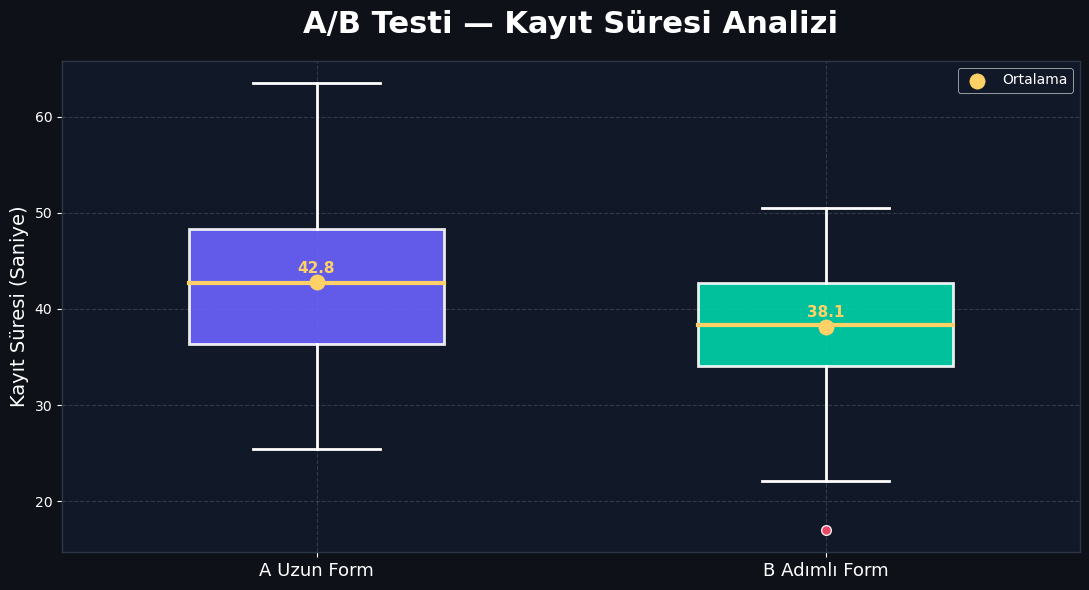

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("dark_background")

# Veri
a_group = df[df["Grup"]=="A_Uzun_Form"]["Kayit_Suresi_Saniye"]
b_group = df[df["Grup"]=="B_Adimli_Form"]["Kayit_Suresi_Saniye"]

# Figure
fig, ax = plt.subplots(figsize=(11,6))

# Arka plan
fig.patch.set_facecolor("#0E1117")
ax.set_facecolor("#111827")

# Boxplot
box = ax.boxplot(
    [a_group, b_group],
    
    patch_artist=True,
    widths=0.5,
    
    boxprops=dict(
        linewidth=2,
        color="white"
    ),
    
    whiskerprops=dict(
        linewidth=2,
        color="white"
    ),
    
    capprops=dict(
        linewidth=2,
        color="white"
    ),
    
    medianprops=dict(
        linewidth=3,
        color="#FFD166"
    ),
    
    flierprops=dict(
        marker='o',
        markersize=7,
        markerfacecolor="#FF4D6D",
        markeredgecolor="white",
        alpha=0.9
    )
)


colors = ["#6C63FF", "#00D4AA"]

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)

ax.set_title(
    "A/B Testi — Kayıt Süresi Analizi",
    fontsize=22,
    fontweight="bold",
    color="white",
    pad=20
)


ax.set_ylabel(
    "Kayıt Süresi (Saniye)",
    fontsize=14,
    color="white"
)


ax.set_xticklabels(
    ["A Uzun Form", "B Adımlı Form"],
    fontsize=13,
    color="white"
)


ax.grid(
    True,
    linestyle="--",
    alpha=0.15,
    color="white"
)


for spine in ax.spines.values():
    spine.set_color("#2D3748")


ax.tick_params(colors="white")


means = [
    np.mean(a_group),
    np.mean(b_group)
]

ax.scatter(
    [1,2],
    means,
    
    color="#FFD166",
    s=120,
    zorder=5,
    
    label="Ortalama"
)

# Ortalama değer yazıları
for i, mean in enumerate(means, start=1):
    
    ax.text(
        i,
        mean + 1,
        f"{mean:.1f}",
        
        ha='center',
        fontsize=11,
        color="#FFD166",
        fontweight="bold"
    )

ax.legend(
    facecolor="#111827",
    edgecolor="white"
)

plt.tight_layout()

plt.show()

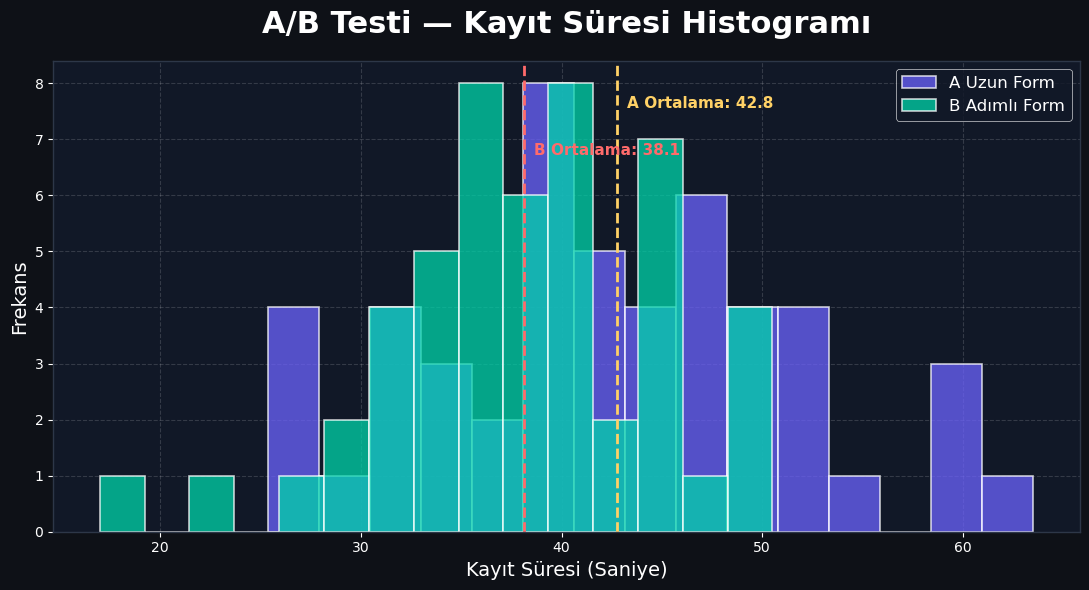

In [11]:
plt.style.use("dark_background")

# Figure
fig, ax = plt.subplots(figsize=(11,6))

# Arka plan renkleri
fig.patch.set_facecolor("#0E1117")
ax.set_facecolor("#111827")

# Histogram A
ax.hist(
    df[df["Grup"]=="A_Uzun_Form"]["Kayit_Suresi_Saniye"],
    
    bins=15,
    alpha=0.75,
    
    color="#6C63FF",
    edgecolor="white",
    linewidth=1.2,
    
    label="A Uzun Form"
)

# Histogram B
ax.hist(
    df[df["Grup"]=="B_Adimli_Form"]["Kayit_Suresi_Saniye"],
    
    bins=15,
    alpha=0.75,
    
    color="#00D4AA",
    edgecolor="white",
    linewidth=1.2,
    
    label="B Adımlı Form"
)


ax.set_title(
    "A/B Testi — Kayıt Süresi Histogramı",
    
    fontsize=22,
    fontweight="bold",
    color="white",
    
    pad=20
)


ax.set_xlabel(
    "Kayıt Süresi (Saniye)",
    
    fontsize=14,
    color="white"
)


ax.set_ylabel(
    "Frekans",
    
    fontsize=14,
    color="white"
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.15,
    color="white"
)


ax.tick_params(colors="white")


for spine in ax.spines.values():
    spine.set_color("#2D3748")


legend = ax.legend(
    facecolor="#111827",
    edgecolor="white",
    fontsize=12
)

for text in legend.get_texts():
    text.set_color("white")


mean_a = df[df["Grup"]=="A_Uzun_Form"]["Kayit_Suresi_Saniye"].mean()
mean_b = df[df["Grup"]=="B_Adimli_Form"]["Kayit_Suresi_Saniye"].mean()

ax.axvline(
    mean_a,
    
    color="#FFD166",
    linestyle="--",
    linewidth=2
)

ax.axvline(
    mean_b,
    
    color="#FF6B6B",
    linestyle="--",
    linewidth=2
)


ax.text(
    mean_a + 0.5,
    ax.get_ylim()[1] * 0.9,
    
    f"A Ortalama: {mean_a:.1f}",
    
    color="#FFD166",
    fontsize=11,
    fontweight="bold"
)

ax.text(
    mean_b + 0.5,
    ax.get_ylim()[1] * 0.8,
    
    f"B Ortalama: {mean_b:.1f}",
    
    color="#FF6B6B",
    fontsize=11,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [12]:
# Grup bazlı temel istatistikler

ci_table = df.groupby("Grup")["Kayit_Suresi_Saniye"].agg(
    ["count", "mean", "std"]
)

# Standard Error (SE)

ci_table["se"] = (
    ci_table["std"] /
    np.sqrt(ci_table["count"])
)

# %95 Güven Aralığı

ci_table["ci95"] = 1.96 * ci_table["se"]

# Alt ve üst sınırlar

ci_table["lower_bound"] = (
    ci_table["mean"] - ci_table["ci95"]
)

ci_table["upper_bound"] = (
    ci_table["mean"] + ci_table["ci95"]
)

# Yuvarlama

ci_table = ci_table.round(2)

ci_table

,count,mean,std,se,ci95,lower_bound,upper_bound
Grup,,,,,,,
A_Uzun_Form,50,42.75,9.33,1.32,2.59,40.17,45.34
B_Adimli_Form,50,38.14,6.99,0.99,1.94,36.20,40.08


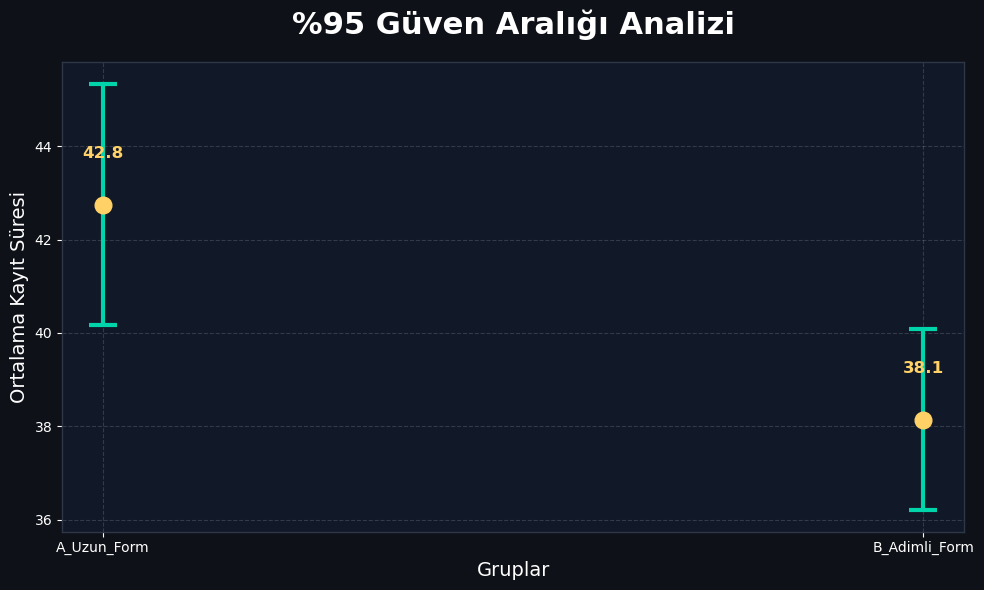

In [13]:
plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(10,6))

# Arka plan
fig.patch.set_facecolor("#0E1117")
ax.set_facecolor("#111827")

# Ortalama noktaları
means = ci_table["mean"]

# Güven aralıkları
errors = ci_table["ci95"]

# Grafik
ax.errorbar(
    ci_table.index,
    means,
    
    yerr=errors,
    
    fmt='o',
    
    color="#FFD166",
    ecolor="#00D4AA",
    
    elinewidth=3,
    capsize=10,
    capthick=3,
    
    markersize=12
)

# Ortalama değer yazıları
for i, value in enumerate(means):
    
    ax.text(
        i,
        value + 1,
        
        f"{value:.1f}",
        
        ha='center',
        fontsize=12,
        color="#FFD166",
        fontweight="bold"
    )

# Başlık
ax.set_title(
    "%95 Güven Aralığı Analizi",
    
    fontsize=22,
    fontweight="bold",
    color="white",
    
    pad=20
)

# Axis label
ax.set_ylabel(
    "Ortalama Kayıt Süresi",
    
    fontsize=14,
    color="white"
)

ax.set_xlabel(
    "Gruplar",
    
    fontsize=14,
    color="white"
)

# Grid
ax.grid(
    True,
    linestyle="--",
    alpha=0.15,
    color="white"
)


ax.tick_params(colors="white")


for spine in ax.spines.values():
    spine.set_color("#2D3748")

plt.tight_layout()

plt.show()

In [16]:
mean_a = ci_table.loc["A_Uzun_Form", "mean"]
mean_b = ci_table.loc["B_Adimli_Form", "mean"]

print("FINAL YORUM")
print("-" * 50)

print(f"A Uzun Form Ortalama Süre: {mean_a:.2f} saniye")
print(f"B Adımlı Form Ortalama Süre: {mean_b:.2f} saniye")

print("\n")

if mean_b < mean_a:
    
    print(
        "B Adımlı Form daha düşük ortalama kayıt süresine sahiptir."
    )
    
    print(
        "Bu durum kullanıcıların kayıt sürecini daha hızlı tamamladığını göstermektedir."
    )
    
    print(
        "Dolayısıyla B tasarımı kullanıcı deneyimi açısından daha başarılı görünmektedir."
    )

else:
    
    print(
        "A Uzun Form daha düşük ortalama kayıt süresine sahiptir."
    )
    
    print(
        "Bu durum kullanıcıların kayıt sürecini daha hızlı tamamladığını göstermektedir."
    )
    
    print(
        "Dolayısıyla A tasarımı kullanıcı deneyimi açısından daha başarılı görünmektedir."
    )

FINAL YORUM
--------------------------------------------------
A Uzun Form Ortalama Süre: 42.75 saniye
B Adımlı Form Ortalama Süre: 38.14 saniye


B Adımlı Form daha düşük ortalama kayıt süresine sahiptir.
Bu durum kullanıcıların kayıt sürecini daha hızlı tamamladığını göstermektedir.
Dolayısıyla B tasarımı kullanıcı deneyimi açısından daha başarılı görünmektedir.
